title: 'UX Recap: Analysis of an experiment'
author:
- |
    Sofia Dahl\
    Dept. Architecture, Design and Media Technology, Aalborg University
    Copenhagen


In [13]:
# To use the statistics module, import into your program
#import statistics 
from scipy import stats
import numpy as np
import pandas as pd

# We also want to plot graphs and histograms
# using matplotlib
import matplotlib.pyplot as plt
# This allows the histogram
# to appear after running the code
%matplotlib inline


Recap content  
===============
1. Forming hypothesis
2. Import the data and check types of data
3. Visualize data
4. Investigate relationships between variables
5. Comparing values (confidence intervals)
6. Check parametric assumptions
7. Student t-test
8. Other ways to do it
      

Forming hypothesis 
===============
We will be analyzing data with ratings from a listening test where two groups heard the same music. Whereas one group (AUDIO) were asked to keep their eyes closed and only listened to the music, the other (AUDIOVISUAL) group were shown a picture showing the musicianc playing the piece 

After listening the groups rated 
 - the skill of the performers
 - the perceived quality  
 - how pleasant the music was.


Q 1: What kind of experimental design is this?

Q 2: What kind of hypothesis would you say is suitable for this experiment?
 

Import the data and initial look
===============
Now you can import data from a listening test

The collected data is stored as comma separated values (csv). We can now import the data. 

In [14]:
# to get help on anything in Python:
#help(pd.DataFrame)  # Capital letters are important in Python.

In [15]:
# We have comma-separated files (.CSV) so we use:
df = pd.read_csv('MusicRatingDataCSV.csv')

# For reading tab-separated txt files, use:
# df = pd.read_csv('DAE1otputdataTAB.txt, delimeter='\t') 

# For reading excel file, use: 
# df = pd.read_excel('DAE1outputdata.xlsx') 

#It is good to check how many rows and columns we have in the data
df.shape


(41, 4)

In [16]:
# print first 4 rows of data:
print(df.head(4))

         GROUP  SKILL  QUALITY  PLEASANTNESS
0        audio     83       37            61
1  audiovisual     40       30            80
2        audio     93       23            75
3        audio     60       40            31


In [17]:
#To get basic statistics for numerical data in df, like: number of elements, mean, standard deviation, min and max value, as well as 25%, 50% and 75% quartiles, use:

df.describe()


,SKILL,QUALITY,PLEASANTNESS
count,41.000000,41.000000,41.000000
mean,70.682927,46.926829,65.243902
std,18.913539,24.764279,22.429646
min,30.000000,0.000000,11.000000
25%,59.000000,30.000000,51.000000
50%,71.000000,40.000000,70.000000
75%,85.000000,64.000000,83.000000
max,100.000000,100.000000,97.000000


Q 3: What kind of data do you have in this data set?

In [18]:
# We can also separate the data set for the two groups

audio_df=df[df['GROUP']=='audio']
audiovisual_df=df[df['GROUP']=='audiovisual']

Visualize data 
===============
As a first step we want to get a first idea of the distribution of data points for the two groups (audio and audiovisual) and the different ratings. Box plots are helpful for this.

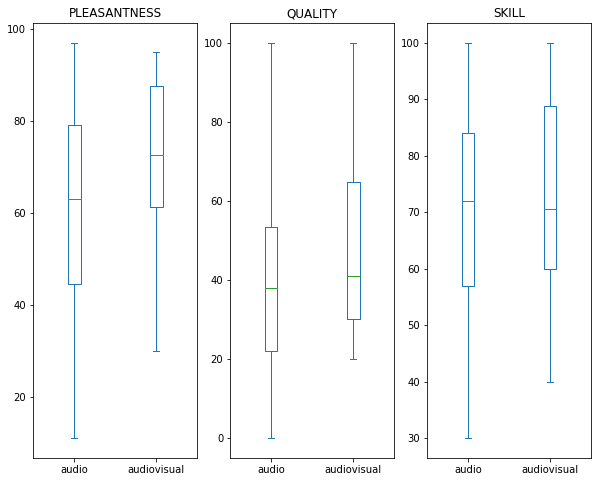

In [19]:
#create grouped box plots
ax = df.plot.box( by="GROUP", figsize=(10, 8))
plt.show()

Then a more detailed view of the distribution for the two groups (audio and audiovisual). Here's an example for the SKILL ratings.

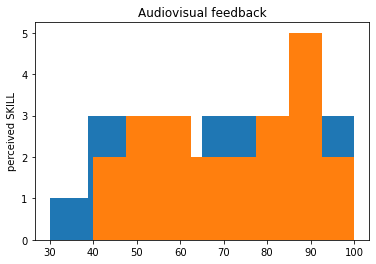

In [20]:
# filtering part of the column - separting data for audio only and audiovisual feedback:

plt.hist(df[df['GROUP']=='audio'].SKILL, bins=8)
plt.ylabel('perceived SKILL')
plt.title('Audio feedback only')
#plt.show()  # uncomment if you want two separate histograms

plt.hist(df[df['GROUP']=='audiovisual'].SKILL, bins=8)
plt.ylabel('perceived SKILL')
plt.title('Audiovisual feedback')
plt.show()  

In [21]:
#dfs.to_csv('modified.csv') #If you want to save modified data

Investigate relationships between variables
=================================

In addition to looking at the distribution of data, it is often useful to check how variables relate to one another. That is, how they correlate In this case, we would for instance be intersted to see if the ratings between different variables show a relationship. This is easily done with a scatter plot.
   

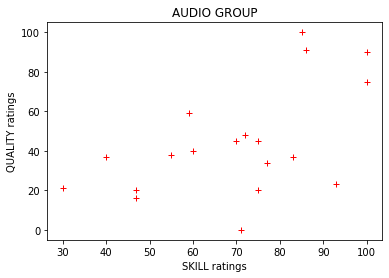

In [22]:
# to plot SKILL vs. QUALITY ratings against each other for the audio group (in red + signs):
plt.plot(df.loc[df['GROUP']=='audio'].SKILL, df.loc[df['GROUP']=='audio'].QUALITY, 'r+')
plt.title('AUDIO GROUP')
plt.xlabel('SKILL ratings')
plt.ylabel('QUALITY ratings')
plt.show()  

If you deem there seems to be a linear relationship we can calculate the pearson correlation coefficient.

In [23]:
#Correlation
correlation_coefficient, p_value = stats.pearsonr(df[df['GROUP']=='audiovisual'].SKILL, df[df['GROUP']=='audiovisual'].QUALITY)

print(f"Correlation Coefficient: {correlation_coefficient}, P-value: {p_value}")

Correlation Coefficient: 0.7343939614169755, P-value: 9.961945103740034e-05


In [24]:
df_audio=

SyntaxError: invalid syntax (584372018.py, line 1)

Comparing values (confidence intervals)
=============================================

Is there a difference in ratings between the two groups?

We can quickly check descriptive stats for a group. 

In [43]:
# We can also do it for only one group
print('audio')
df[df['GROUP']=='audio'].describe()


audio


,SKILL,QUALITY,PLEASANTNESS
count,19.000000,19.000000,19.000000
mean,69.736842,44.157895,60.631579
std,19.840593,27.645098,24.549747
min,30.000000,0.000000,11.000000
25%,57.000000,22.000000,44.500000
50%,72.000000,38.000000,63.000000
75%,84.000000,53.500000,79.000000
max,100.000000,100.000000,97.000000


But in order to say something more about how precise the mean is, we need the confidence interval.

In [62]:
# Find 95% confidence interval for the mean of audio only group SKILL ratings
stats.t.interval(confidence=0.95, df=len(audio_df.SKILL)-1, loc=np.mean(audio_df.SKILL), scale=stats.sem(audio_df.SKILL))


(60.173982481099934, 79.2997017294264)

Q: Look back at the box plot and see where these confidence interval are and how much they overlap between groups.

Check parametric assumptions
=================================

To perform parametric tests like t-tests to compare the measures between the groups, we need to check assumptions. 
We can start by looking more at normality of data (in addition to the histograms earlier).

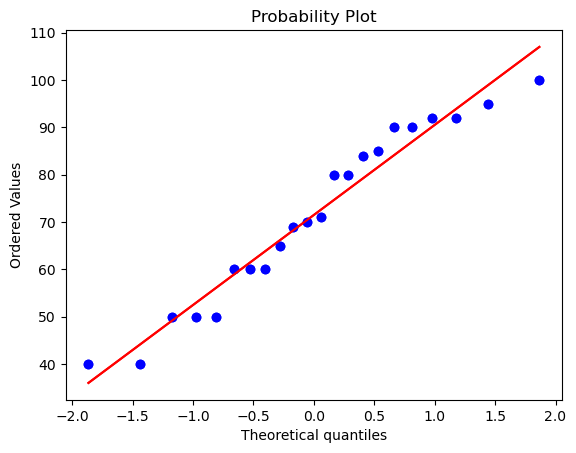

In [35]:


# Use stats.probplot to make a qq-plot
stats.probplot(df[df['GROUP']=='audiovisual'].SKILL, plot=plt);

plt.show() 


Shapiro Wilk tests can also be used to check for normality. 

In [64]:
#Shapiro test of Normality for the hours spent watching streams collumn
stat, p, = stats.shapiro(df[df['GROUP']=='audiovisual'].SKILL)
print('Shapiro-Wilk=%.3f, p=%.3f' % (stat, p))


Shapiro-Wilk=0.942, p=0.221


Now do it also for the other group (and ratings).

Another assumption is that the variance is approximately equal between the two groups. This we can check see in the plotting of data, but we also use a Levene's test to check the null hypothesis that the variances do not differ.

In [65]:
#Levene test of homogeneity
stat, p = stats.levene(df[df['GROUP']=='audio'].SKILL,
                 df[df['GROUP']=='audiovisual'].SKILL)

print(f'Levene test statistic: {stat}, p-value: {p}')


Levene test statistic: 0.002182155754550301, p-value: 0.9629799221765623


Student t-test
=================================
If we have continous data that does not violate the above assumptions we can proceed with a t-test to investigate if there is a significant difference between groups. 




Q: What type of t-test should you use for this type of experimental design and data?

In [66]:
#T test (this is a two-sided T test)
t_stat, p_value = stats.ttest_ind(df[df['GROUP']=='audio'].SKILL,
                 df[df['GROUP']=='audiovisual'].SKILL)

print(f"T-statistic: {t_stat}, P-value: {p_value}")



T-statistic: -0.2942377836776318, P-value: 0.7701366351958985


Q: What does the values above mean? How do you interpret the result of the test in view of the original hypothesis?

Other ways to do it
===================
Be aware that there are several ways to do many things of what we have gone through here above. It's important that you understand what is going on, but there are other packages (such as pingouin) that can perform tests and give infomration on both effect size and confidence intervals. 

In [68]:
import numpy as np
import pingouin as pg

# T-test
pg.ttest(df[df['GROUP']=='audio'].SKILL, df[df['GROUP']=='audiovisual'].SKILL)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-0.292706,37.206204,two-sided,0.771373,"[-13.97, 10.44]",0.092151,0.317,0.059492
